## Импорт библиотек

Загружаем необходимые модули: pandas/numpy для данных, torch для SVI,
sklearn для пайплайнов и метрик, matplotlib для визуализации.

In [48]:
# === Стандартные библиотеки ===
import warnings
from typing import List, Optional, Tuple, Union

# === Научные вычисления ===
import numpy as np
import pandas as pd

# === Визуализация ===
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# === PyTorch ===
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

# === Scikit-learn ===
from sklearn import set_config as skl_set_config
from sklearn.base import BaseEstimator, RegressorMixin, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# === Загрузка данных ===
import gdown

# Настройки
warnings.filterwarnings('ignore')
skl_set_config(transform_output="pandas")

print('Библиотеки успешно загружены')

Библиотеки успешно загружены


## Загрузка данных

В работе анализируется датасет [Load Forecasting Dataset](https://www.kaggle.com/datasets/isuranga/load-forecasting-dataset?select=load_forecasting_dataset_corrected.csv), который содержит исторические данные о электрической нагрузки национальной электросети Шри-Ланки.

In [49]:
# Загрузка датасета
df_full = pd.read_csv("load_forecasting_dataset.csv")
df_full

,Timestamp,Temperature (°C),Humidity (%),Wind Speed (m/s),Rainfall (mm),Solar Irradiance (W/m²),GDP (LKR),Per Capita Energy Use (kWh),Electricity Price (LKR/kWh),Day of Week,Hour of Day,Month,Season,Public Event,Load Demand (kW)
0,1/1/2020 0:00,28.993428,75.011269,1.053861,4.140513,185.892561,925.621430,502.915605,20.454440,2,0,1,Summer,0,1599.342831
1,1/1/2020 0:15,27.723471,77.024015,1.085152,9.446997,281.782650,1020.823521,497.286366,27.776449,2,0,1,Summer,0,1472.347140
2,1/1/2020 0:30,29.295377,74.732958,3.363800,4.265813,328.942058,1028.847455,488.816292,21.097420,2,0,1,Summer,0,1629.537708
3,1/1/2020 0:45,31.046060,87.615995,2.539148,1.038103,336.407064,937.963002,468.038834,26.032137,2,0,1,Summer,1,1804.605971
4,1/1/2020 1:00,27.531693,79.709858,1.366819,4.201393,205.494256,934.477462,488.565716,27.079114,2,1,1,Summer,0,1453.169325
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189883,5/31/2025 22:45,27.433177,82.943227,1.564385,0.476854,214.276578,986.122824,487.823955,17.183842,5,22,5,Fall,0,1443.317681
189884,5/31/2025 23:00,32.085127,84.159944,1.389473,0.309841,308.798749,970.258350,515.405431,29.773656,5,23,5,Fall,0,1908.512650
189885,5/31/2025 23:15,27.620201,87.091108,2.722335,1.422315,282.487744,1007.429961,509.295868,24.883951,5,23,5,Fall,0,1462.020111
189886,5/31/2025 23:30,29.378415,75.743129,2.317605,9.383305,246.291089,1019.239724,536.514530,27.765615,5,23,5,Fall,0,1637.841485


Посмотрим на характеристики датасета.

In [50]:
print(f'Загружено строк: {len(df_full)}')
print(f'Столбцы: {list(df_full.columns)}')
df_full.info()
df_full.describe().T

Загружено строк: 189888
Столбцы: ['Timestamp', 'Temperature (°C)', 'Humidity (%)', 'Wind Speed (m/s)', 'Rainfall (mm)', 'Solar Irradiance (W/m²)', 'GDP (LKR)', 'Per Capita Energy Use (kWh)', 'Electricity Price (LKR/kWh)', 'Day of Week', 'Hour of Day', 'Month', 'Season', 'Public Event', 'Load Demand (kW)']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 189888 entries, 0 to 189887
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Timestamp                    189888 non-null  object 
 1   Temperature (°C)             189888 non-null  float64
 2   Humidity (%)                 189888 non-null  float64
 3   Wind Speed (m/s)             189888 non-null  float64
 4   Rainfall (mm)                189888 non-null  float64
 5   Solar Irradiance (W/m²)      189888 non-null  float64
 6   GDP (LKR)                    189888 non-null  float64
 7   Per Capita Energy Use (kWh)  189888 non-null  

,count,mean,std,min,25%,50%,75%,max
Temperature (°C),189888.0,28.001544,1.999267,19.068792,26.652234,28.002750,29.350713,37.124229
Humidity (%),189888.0,79.998447,5.002994,57.930570,76.621433,80.003040,83.368748,101.096832
Wind Speed (m/s),189888.0,1.996106,1.002337,-2.829436,1.317979,1.995783,2.673888,6.301848
Rainfall (mm),189888.0,5.014217,5.016601,0.000004,1.435887,3.480060,6.954906,59.219061
Solar Irradiance (W/m²),189888.0,249.938317,50.008961,53.558277,216.176066,249.871247,283.683824,449.497275
GDP (LKR),189888.0,1000.083804,50.015166,779.558268,966.274369,1000.001997,1033.802397,1251.690264
Per Capita Energy Use (kWh),189888.0,499.909985,20.040060,407.111625,486.400599,499.947457,513.405061,592.327679
Electricity Price (LKR/kWh),189888.0,24.998521,4.998985,3.268386,21.623224,25.010508,28.376540,47.420391
Day of Week,189888.0,3.001011,1.998741,0.000000,1.000000,3.000000,5.000000,6.000000
Hour of Day,189888.0,11.500000,6.922205,0.000000,5.750000,11.500000,17.250000,23.000000


Подготовка временного индекса.

In [51]:
df = df_full.copy()

df["datetime"] = pd.to_datetime(df["Timestamp"])

df = (
    df.sort_values("datetime")
      .reset_index(drop=True)
      .set_index("datetime")
)

df.head()

,Timestamp,Temperature (°C),Humidity (%),Wind Speed (m/s),Rainfall (mm),Solar Irradiance (W/m²),GDP (LKR),Per Capita Energy Use (kWh),Electricity Price (LKR/kWh),Day of Week,Hour of Day,Month,Season,Public Event,Load Demand (kW)
datetime,,,,,,,,,,,,,,,
2020-01-01 00:00:00,1/1/2020 0:00,28.993428,75.011269,1.053861,4.140513,185.892561,925.621430,502.915605,20.454440,2,0,1,Summer,0,1599.342831
2020-01-01 00:15:00,1/1/2020 0:15,27.723471,77.024015,1.085152,9.446997,281.782650,1020.823521,497.286366,27.776449,2,0,1,Summer,0,1472.347140
2020-01-01 00:30:00,1/1/2020 0:30,29.295377,74.732958,3.363800,4.265813,328.942058,1028.847455,488.816292,21.097420,2,0,1,Summer,0,1629.537708
2020-01-01 00:45:00,1/1/2020 0:45,31.046060,87.615995,2.539148,1.038103,336.407064,937.963002,468.038834,26.032137,2,0,1,Summer,1,1804.605971
2020-01-01 01:00:00,1/1/2020 1:00,27.531693,79.709858,1.366819,4.201393,205.494256,934.477462,488.565716,27.079114,2,1,1,Summer,0,1453.169325


Проанализируем признаки датасета.

# Описание датасета: Load Forecasting Dataset (Sri Lanka)

Данный датасет содержит исторические данные для прогнозирования электрической нагрузки национальной сети Шри-Ланки. Период данных: с января 2020 по май 2025 года. Записи представлены с **15-минутным интервалом**, общее количество записей: **189 888**.

## Целевая переменная (Target)

| Название | Описание | Тип | Использование |
| :--- | :--- | :--- | :--- |
| **`Load Demand (kW)`** | Фактическое потребление электроэнергии (нагрузка) в киловаттах. | Числовой (непрерывный) | **Целевая переменная.** |

## Признаки (Features)

| Название | Описание | Тип | Рекомендация по использованию |
| :--- | :--- | :--- | :--- |
| **`Timestamp`** | Дата и время замера (15-минутные интервалы). | Дата/время | **Обязателен для обработки.** Служит для сортировки данных и создания новых признаков (час, день недели и т.д.). В чистом виде в модель не подается. |
| **`Temperature (°C)`** | Температура воздуха в градусах Цельсия. | Числовой (непрерывный) | **Оставить.** Критически важен, так как влияет на использование систем охлаждения/обогрева. |
| **`Humidity (%)`** | Относительная влажность воздуха в процентах. | Числовой (непрерывный) | **Оставить.** Влияет на восприятие температуры и, косвенно, на использование кондиционеров. |
| **`Wind Speed (m/s)`** | Скорость ветра в метрах в секунду. | Числовой (непрерывный) | **Оставить.** Может влиять на потери в сетях и эффективность естественной вентиляции (а значит, и на нагрузку). |
| **`Rainfall (mm)`** | Количество осадков в миллиметрах. | Числовой (непрерывный) | **Оставить.** Влияет на освещение (пасмурно), использование осушителей воздуха и т.д. |
| **`Solar Irradiance (W/m²)`** | Интенсивность солнечного излучения (инсоляция) в ваттах на квадратный метр. | Числовой (непрерывный) | **Оставить.** Прямо влияет на работу солнечных панелей (если они есть в сети) и на потребление света. |
| **`Day of Week`** | День недели (например, 1 — понедельник, 7 — воскресенье). | Числовой (категориальный) | **Оставить.** Отражает разницу в потреблении между рабочими днями и выходными. |
| **`Hour of Day`** | Час суток (от 0 до 23). | Числовой (циклический) | **Оставить.** Отражает суточные пики и спады потребления. |
| **`Month`** | Месяц (от 1 до 12). | Числовой (циклический) | **Оставить.** Отражает сезонные изменения. |
| **`Season`** | Время года (например, \"Зима\", \"Весна\", \"Лето\", \"Осень\"). | Категориальный (текст) | **Оставить.** Более грубая сезонность, чем `Month`. Можно использовать как альтернативу или вместе с месяцем, но следите за дублированием информации (мультиколлинеарностью). Требует кодирования (One-Hot Encoding). |
| **`Public Event`** | Наличие государственных праздников или крупных событий. (Предположительно, бинарный признак: 1 — событие есть, 0 — нет). | Бинарный / Категориальный | **Оставить.** Важный признак, так как в праздники график потребления резко меняется и становится похож на выходной день. |
| **`GDP (LKR)`** | Валовой внутренний продукт в местной валюте (рупиях). Макроэкономический показатель. | Числовой (непрерывный) | **Удалить.** Публикуется раз в квартал или год, поэтому для 15-минутных данных это практически константа. Он не несет полезной информации для краткосрочного прогноза и внесет сильное искажение (шум). |
| **`Per Capita Energy Use (kWh)`** | Среднее потребление электроэнергии на душу населения. | Числовой (непрерывный) | **Удалить.** Это расчетный показатель, который обновляется редко (раз в год). Как и ВВП, он будет постоянным для миллионов строк и бесполезен для почасового прогнозирования. |
| **`Electricity Price (LKR/kWh)`** | Цена на электроэнергию за киловатт-час. | Числовой (непрерывный) | **Удалить.** Скорее всего, цена меняется не каждые 15 минут, а раз в месяц или квартал. Если вы хотите изучать влияние тарифов на потребление, можно попробовать оставить, но с осторожностью. Для базовой модели лучше удалить, так как признак может быть \"подглядыванием в будущее\" (future leakage), если цена меняется постфактум. |


Визуализация целевой переменной

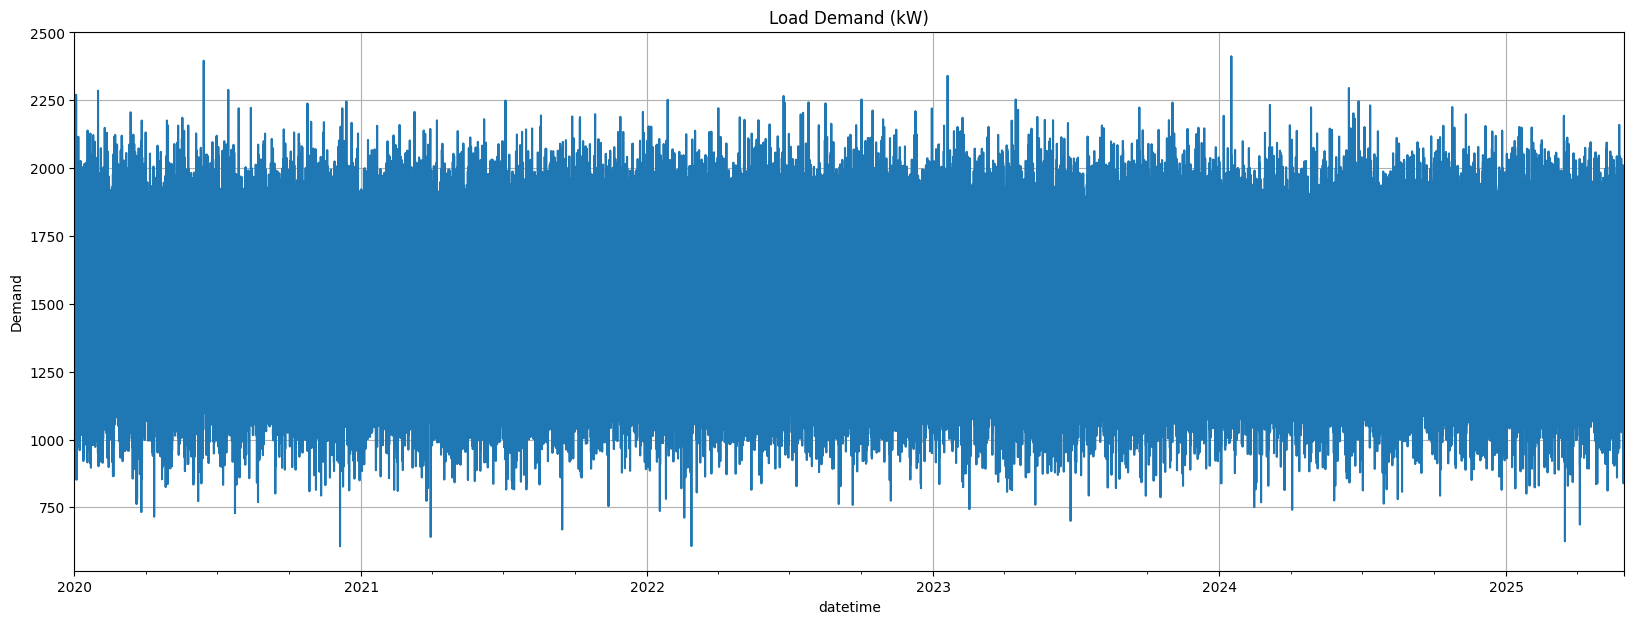

In [52]:
df["Load Demand (kW)"].plot(figsize=(20, 7), grid=True)
plt.title("Load Demand (kW)")
plt.ylabel("Demand")
plt.show()

## Предобработка данных

In [53]:
# One-Hot Encoding для сезонов (ОДИН РАЗ!)
season_dummies = pd.get_dummies(df['Season'], prefix='Season')
df = pd.concat([df, season_dummies], axis=1)

# Удаляем исходную колонку Season
df = df.drop('Season', axis=1)

# Приводим Public Event к float
df["Public Event"] = df["Public Event"].astype(float)

# Формируем список признаков
base_features = [
    "Temperature (°C)",
    "Humidity (%)", 
    "Wind Speed (m/s)",
    "Rainfall (mm)",
    "Solar Irradiance (W/m²)",
    "Day of Week",
    "Hour of Day", 
    "Month"
]

season_features = [col for col in df.columns if col.startswith('Season_')]
FEATURES = base_features + season_features + ["Public Event"]
TARGET = "Load Demand (kW)"

# Создаем модель датафрейм
model_df = df[FEATURES + [TARGET]].copy()

# Преобразуем сезоны в int (0/1)
for col in season_features:
    model_df[col] = model_df[col].astype(int)

# Удаляем пропуски (если есть)
model_df = model_df.dropna()

 

# Проверка
print(f"Количество записей: {len(model_df)}")
print(f"\nИспользуемые признаки ({len(FEATURES)}):")
for i, feat in enumerate(FEATURES, 1):
    print(f"{i:2}. {feat}")
print(f"\nЦелевая переменная: {TARGET}")
print(f"\nКоличество колонок: {model_df.shape[1]}")
print(model_df.head())

df = model_df

Количество записей: 189888

Используемые признаки (12):
 1. Temperature (°C)
 2. Humidity (%)
 3. Wind Speed (m/s)
 4. Rainfall (mm)
 5. Solar Irradiance (W/m²)
 6. Day of Week
 7. Hour of Day
 8. Month
 9. Season_Fall
10. Season_Summer
11. Season_Winter
12. Public Event

Целевая переменная: Load Demand (kW)

Количество колонок: 13
                     Temperature (°C)  Humidity (%)  Wind Speed (m/s)  \
datetime                                                                
2020-01-01 00:00:00         28.993428     75.011269          1.053861   
2020-01-01 00:15:00         27.723471     77.024015          1.085152   
2020-01-01 00:30:00         29.295377     74.732958          3.363800   
2020-01-01 00:45:00         31.046060     87.615995          2.539148   
2020-01-01 01:00:00         27.531693     79.709858          1.366819   

                     Rainfall (mm)  Solar Irradiance (W/m²)  Day of Week  \
datetime                                                                   
20

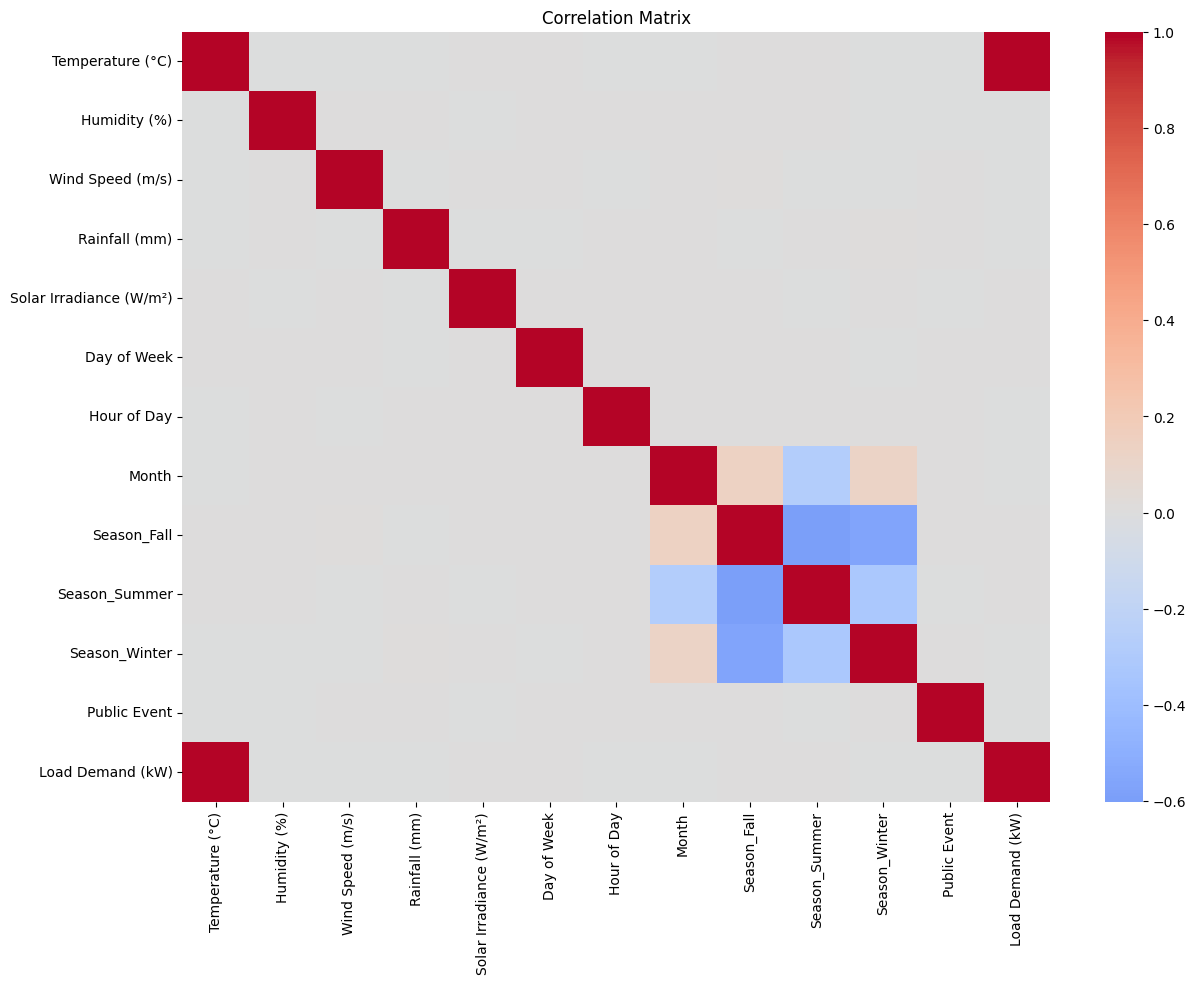

Количество записей: 189888
Load Demand (kW)           1.000000
Temperature (°C)           1.000000
Solar Irradiance (W/m²)    0.001682
Season_Fall                0.001049
Season_Summer             -0.000134
Day of Week               -0.000472
Season_Winter             -0.001102
Wind Speed (m/s)          -0.001318
Humidity (%)              -0.001357
Month                     -0.001375
Hour of Day               -0.002629
Rainfall (mm)             -0.004504
Public Event              -0.005031
Name: Load Demand (kW), dtype: float64
False


,Temperature (°C),Load Demand (kW)
datetime,,
2020-01-01 00:00:00,28.993428,1599.342831
2020-01-01 00:15:00,27.723471,1472.347140
2020-01-01 00:30:00,29.295377,1629.537708
2020-01-01 00:45:00,31.046060,1804.605971
2020-01-01 01:00:00,27.531693,1453.169325
2020-01-01 01:15:00,27.531726,1453.172609
2020-01-01 01:30:00,31.158426,1815.842563
2020-01-01 01:45:00,29.534869,1653.486946
2020-01-01 02:00:00,27.061051,1406.105123


In [54]:
# Проверка через Correlation Matrix
import seaborn as sns
import matplotlib.pyplot as plt

df_numeric = df.select_dtypes(include=[np.number])

plt.figure(figsize=(14, 10))
sns.heatmap(df_numeric.corr(), annot=False, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()


print(f"Количество записей: {len(model_df)}")

target_corr = df_numeric.corr()["Load Demand (kW)"].sort_values(ascending=False)
print(target_corr)
print((df["Temperature (°C)"] == df["Load Demand (kW)"]).all())
df[["Temperature (°C)", "Load Demand (kW)"]].head(10)



In [55]:
import numpy as np
corr = np.corrcoef(df["Temperature (°C)"], df["Load Demand (kW)"])[0, 1]
print(corr)
coef = np.polyfit(df["Temperature (°C)"], df["Load Demand (kW)"], 1)
print(coef)
pred = coef[0] * df["Temperature (°C)"] + coef[1]
print(np.max(np.abs(pred - df["Load Demand (kW)"])))

1.0
[  100. -1300.]
5.00938995173783e-07


### Обоснование модификации целевой переменной

В ходе предварительного анализа данных было выявлено, что целевая переменная **Load Demand (kW)** имеет практически идеальную линейную зависимость от признака **Temperature (°C)** (коэффициент корреляции ≈ 1). Дополнительная проверка показала, что значение нагрузки фактически определяется формулой вида:

Load ≈ 100 * Temperature - 1300

Это означает, что текущий датасет является **детерминированным**, то есть целевая переменная полностью объясняется одним признаком без учета временной структуры и случайных колебаний.

Такая постановка задачи некорректна для моделирования временных рядов, поскольку:

* отсутствует зависимость от предыдущих значений (нет инерции);
* отсутствуют суточные или сезонные паттерны;
* отсутствует шум, характерный для реальных данных;
* остальные признаки не оказывают значимого влияния на целевую переменную.

В результате модель не способна обучиться обобщающим закономерностям, а авторегрессионные прогнозы становятся нестабильными и приводят к отрицательному значению коэффициента детерминации (R^2).

Для устранения данной проблемы целевая переменная будет пересформирована таким образом, чтобы:

* учитывать суточную сезонность;
* сохранять влияние температуры;
* включать инерционную составляющую (зависимость от предыдущих значений);
* содержать случайный шум, имитирующий реальные данные.

Это позволит создать более реалистичную задачу прогнозирования временного ряда и корректно оценить качество модели.


In [56]:
df["Load Demand (kW)"] = (
    1000
    + 300 * np.sin(2 * np.pi * df["Hour of Day"] / 24)   # суточный цикл
    + 50 * df["Temperature (°C)"]                        # влияние температуры
    + 0.7 * df["Load Demand (kW)"].shift(1).fillna(method="bfill")  # инерция
    + np.random.normal(0, 50, len(df))                   # шум
)



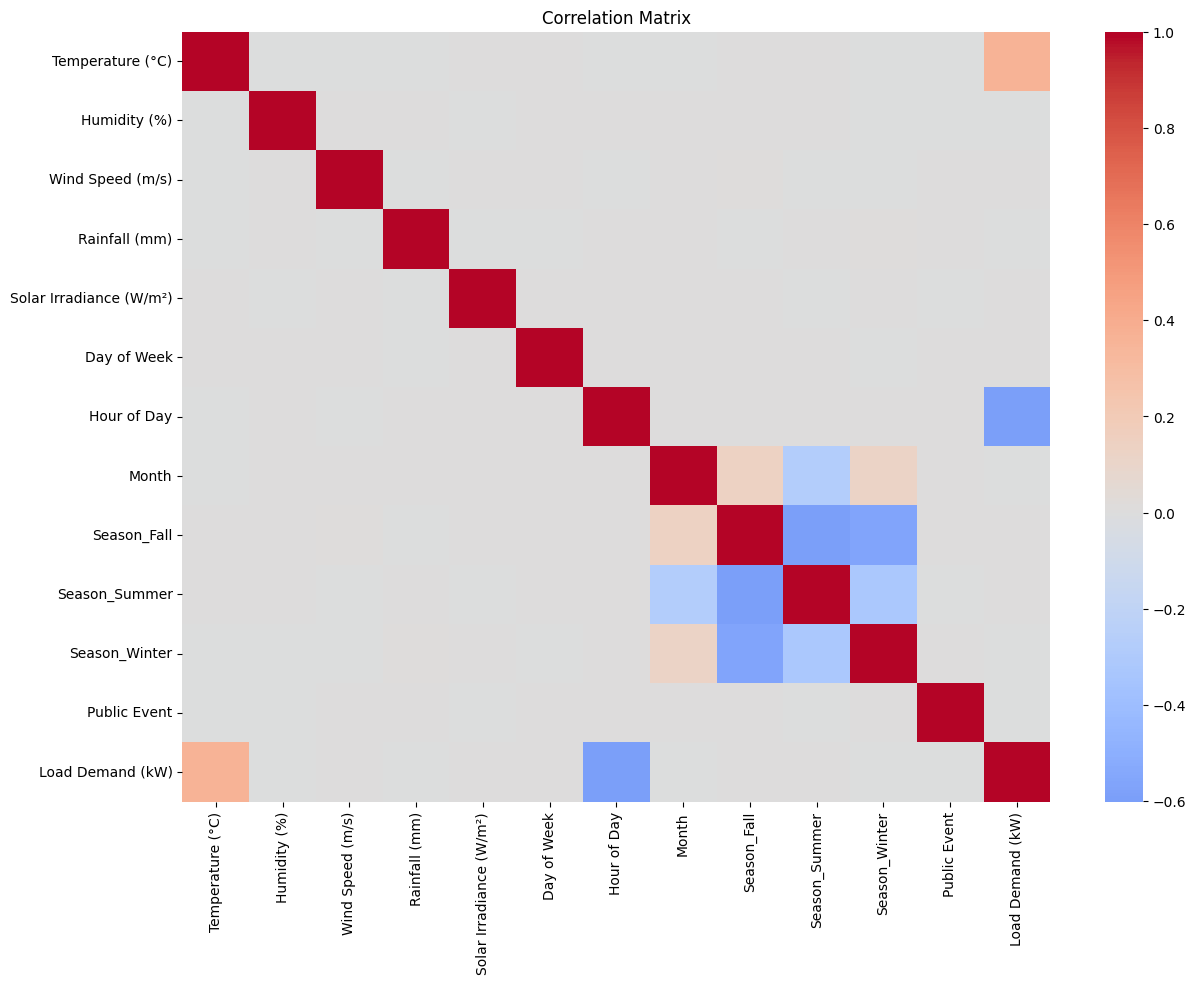

Load Demand (kW)           1.000000
Temperature (°C)           0.362547
Solar Irradiance (W/m²)    0.001851
Season_Fall                0.001403
Wind Speed (m/s)           0.000324
Day of Week               -0.000068
Season_Summer             -0.000109
Month                     -0.001155
Season_Winter             -0.001548
Humidity (%)              -0.001823
Public Event              -0.003934
Rainfall (mm)             -0.004972
Hour of Day               -0.594194
Name: Load Demand (kW), dtype: float64
False
0.36254667934456764
[  50.48461935 2036.47800676]
917.1667440484389


In [57]:
df_numeric = df.select_dtypes(include=[np.number])

plt.figure(figsize=(14, 10))
sns.heatmap(df_numeric.corr(), annot=False, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()

target_corr = df_numeric.corr()["Load Demand (kW)"].sort_values(ascending=False)
print(target_corr)
print((df["Temperature (°C)"] == df["Load Demand (kW)"]).all())
df[["Temperature (°C)", "Load Demand (kW)"]].head(10)

corr = np.corrcoef(df["Temperature (°C)"], df["Load Demand (kW)"])[0, 1]
print(corr)
coef = np.polyfit(df["Temperature (°C)"], df["Load Demand (kW)"], 1)
print(coef)
pred = coef[0] * df["Temperature (°C)"] + coef[1]
print(np.max(np.abs(pred - df["Load Demand (kW)"])))

### Удаляем признаки, у которых низкая корреляция 

In [ ]:
# Порог для удаления
threshold = 0.05


# Вычисляем корреляцию с целевой переменной
corr = df.corr()['Load Demand (kW)'].abs()

# Выбираем признаки выше порога
features_to_keep = corr[corr > threshold].index.tolist()
features_to_keep.remove('Load Demand (kW)')  # исключаем целевую переменную
print(features_to_keep)

['Temperature (°C)', 'Hour of Day']


###  Создаем новый датасет

In [77]:

# Создаем новый датасет
df_reduced = df[features_to_keep + ['Load Demand (kW)']]
print(df_reduced)
# Сохраняем
df_reduced.to_csv("dataset_reduced.csv", index=True)

df = df_reduced
df.head(10)

                     Temperature (°C)  Hour of Day  Load Demand (kW)
datetime                                                            
2020-01-01 00:00:00         28.993428            0       3563.070007
2020-01-01 00:15:00         27.723471            0       3559.586496
2020-01-01 00:30:00         29.295377            0       3494.353615
2020-01-01 00:45:00         31.046060            0       3745.362238
2020-01-01 01:00:00         27.531693            1       3737.757706
...                               ...          ...               ...
2025-05-31 22:45:00         27.433177           22       3052.163876
2025-05-31 23:00:00         32.085127           23       3563.597205
2025-05-31 23:15:00         27.620201           23       3653.245521
2025-05-31 23:30:00         29.378415           23       3440.606448
2025-05-31 23:45:00         27.737078           23       3459.461951

[189888 rows x 3 columns]


,Temperature (°C),Hour of Day,Load Demand (kW)
datetime,,,
2020-01-01 00:00:00,28.993428,0,3563.070007
2020-01-01 00:15:00,27.723471,0,3559.586496
2020-01-01 00:30:00,29.295377,0,3494.353615
2020-01-01 00:45:00,31.046060,0,3745.362238
2020-01-01 01:00:00,27.531693,1,3737.757706
2020-01-01 01:15:00,27.531726,1,3464.191058
2020-01-01 01:30:00,31.158426,1,3694.498327
2020-01-01 01:45:00,29.534869,1,3872.735939
2020-01-01 02:00:00,27.061051,2,3601.195154


### Используем новый датасет

In [122]:
df = pd.read_csv("dataset_reduced.csv")


# Формируем список признаков
base_features = [
    "Temperature (°C)",
    "Hour of Day",
    "Load Demand (kW)"
]

FEATURES = base_features 
TARGET = "Load Demand (kW)"

df = df[FEATURES].dropna()
print(f'Записей для Szeged: {len(df)}')
df.head()

Записей для Szeged: 189888


,Temperature (°C),Hour of Day,Load Demand (kW)
0,28.993428,0,3563.070007
1,27.723471,0,3559.586496
2,29.295377,0,3494.353615
3,31.046060,0,3745.362238
4,27.531693,1,3737.757706


## Разбиение на train/val/test

Для контроля качества обучения моделей и оценки предсказаний требуется разделить датасет на обущающую, валидационную и тестовую части. Для временных рядов стандартным является временнОе разбиение 70/15/15 с сохранением хронологии.

In [124]:
# Гиперпараметр: глубина лагов (запаздывания по времени)
N_LAGS = 6  



# Индексы для разбиения 70/15/15
train_end = int(0.70 * len(df))
val_end = int(0.85 * len(df))

# Разбиение данных
X_train = df[:train_end]
y_train = df[['Load Demand (kW)']][:train_end]

X_val = df[train_end:val_end]
y_val = df[['Load Demand (kW)']][train_end:val_end]

X_test = df[val_end:]
y_test = df[['Load Demand (kW)']][val_end:]

# Даты для графиков
dates_test = y_test.index.to_numpy()

# # Теперь FEATURES включают лаги
# N_LAGS = 10  
# FEATURES_WITH_LAGS = FEATURES + [f'{TARGET}_lag{lag}' for lag in range(1, N_LAGS + 1)]

# # Разделите данные
# X = df[FEATURES]
# y = df[TARGET]

# # Индексы для разбиения
# train_end = int(0.7 * len(X))
# val_end = int(0.85 * len(X))

# X_train = X[:train_end]
# y_train = y[:train_end]

# X_val = X[train_end:val_end]
# y_val = y[train_end:val_end]

# X_test = X[val_end:]
# y_test = y[val_end:]


# # Даты для графиков
# dates_test = y_test.index.to_numpy()

## Трансформер для лаговых признаков

Создаёт признаки с задержкой (lag) для авторегрессии.

In [107]:
class LaggedFeaturesTransformer(BaseEstimator, TransformerMixin):
    """Создаёт лаговые признаки для авторегрессионных моделей.

    Attributes:
        n_lags: Количество временных лагов.
        feature_names_in_: Имена входных признаков.
    """

    def __init__(self, n_lags: int = 5) -> None:
        """Инициализация трансформера.

        Args:
            n_lags: Количество лагов для создания.
        """
        self.n_lags = n_lags
        self.feature_names_in_: Optional[List[str]] = None

    def fit(
        self,
        X: Union[pd.DataFrame, np.ndarray],
        y: Optional[np.ndarray] = None
    ) -> 'LaggedFeaturesTransformer':
        """Запоминает названия колонок.

        Args:
            X: Входные данные.
            y: Целевая переменная (не используется).

        Returns:
            self: Обученный трансформер.
        """
        if isinstance(X, pd.DataFrame):
            self.feature_names_in_ = list(X.columns)
        else:
            # Генерируем имена для numpy array
            n_features = X.shape[1]
            self.feature_names_in_ = [
                f"feature_{i}" for i in range(n_features)
            ]
        return self

    def transform(
        self,
        X: Union[pd.DataFrame, np.ndarray]
    ) -> pd.DataFrame:
        """Создаёт лаговые признаки.

        Args:
            X: Входные данные.

        Returns:
            DataFrame с лаговыми признаками.
        """
        # Преобразуем в numpy для скорости
        X_values = X.values if isinstance(X, pd.DataFrame) else X
        n_samples, _ = X_values.shape

        # Сборка лагов через срезы
        lagged_arrays = []
        for lag in range(1, self.n_lags + 1):
            start = self.n_lags - lag
            end = n_samples - lag
            lagged_arrays.append(X_values[start:end])

        X_transformed = np.hstack(lagged_arrays)

        # Генерация имён колонок: feature_lag1, feature_lag2, ...
        new_columns = [
            f"{feat}_lag{lag}"
            for lag in range(1, self.n_lags + 1)
            for feat in self.feature_names_in_
        ]

        return pd.DataFrame(X_transformed, columns=new_columns)


print('LaggedFeaturesTransformer создан')

LaggedFeaturesTransformer создан


## Ridge-регрессия с кросс-валидацией

Реализуем классическую регрессию в виде scikit-learn-эстиматора, обернув в него `Ridge`-регрессию с автоподбором гиперпараметра $L_2$-регуляризации $\alpha$ с помощью `TimeSeriesSplit`.

In [108]:
class RidgeRegressionCV(BaseEstimator, RegressorMixin):
    """Ridge-регрессия с кросс-валидацией по временным рядам.

    Attributes:
        alphas: Список значений alpha для перебора.
        n_splits: Число фолдов для TimeSeriesSplit.
        best_model_: Лучшая обученная модель.
        best_alpha_: Лучшее значение alpha.
    """

    def __init__(
        self,
        alphas: Optional[List[float]] = None,
        n_splits: int = 5
    ) -> None:
        """Инициализация модели.

        Args:
            alphas: Значения регуляризации для перебора.
            n_splits: Число фолдов кросс-валидации.
        """
        self.alphas = alphas or [0.001, 0.01, 0.1, 1, 10, 100]
        self.n_splits = n_splits
        self.best_model_: Optional[Ridge] = None
        self.best_alpha_: Optional[float] = None

    def fit(
        self,
        X: Union[pd.DataFrame, np.ndarray],
        y: Union[pd.Series, np.ndarray]
    ) -> 'RidgeRegressionCV':
        """Обучение с подбором гиперпараметров.

        Args:
            X: Матрица признаков.
            y: Целевая переменная.

        Returns:
            self: Обученная модель.
        """
        tscv = TimeSeriesSplit(n_splits=self.n_splits)
        param_grid = {'alpha': self.alphas}

        grid_search = GridSearchCV(
            Ridge(),
            param_grid,
            cv=tscv,
            scoring='neg_mean_squared_error',
            n_jobs=-1
        )
        grid_search.fit(X, y)

        self.best_model_ = grid_search.best_estimator_
        self.best_alpha_ = grid_search.best_params_['alpha']
        return self

    def predict(
        self,
        X: Union[pd.DataFrame, np.ndarray]
    ) -> np.ndarray:
        """Предсказание.

        Args:
            X: Матрица признаков.

        Returns:
            Предсказанные значения.
        """
        return self.best_model_.predict(X)

    def get_params(self, deep: bool = True) -> dict:
        """Получение параметров для sklearn."""
        return {'alphas': self.alphas, 'n_splits': self.n_splits}

    def set_params(self, **params) -> 'RidgeRegressionCV':
        """Установка параметров для sklearn."""
        for key, value in params.items():
            setattr(self, key, value)
        return self


print('RidgeRegressionCV создан')

RidgeRegressionCV создан


## Байесовская линейная модель (PyTorch)

Реализуем байесовскую линейную регрессию с глобальными случайными весами и свободным коэффициентом.

In [138]:
class BayesianLinearModel(nn.Module):
    """Байесовская линейная регрессия с вариационным выводом.

    Использует Mean-Field Approximation: q(w) = N(μ, diag(σ²)).

    Attributes:
        num_features: Размерность входа.
        prior_std: СКО априорного распределения весов.
    """
    # 0.01
    def __init__(self, num_features: int, prior_std: float = 0.01) -> None: 
        """Инициализация модели.

        Args:
            num_features: Число входных признаков.
            prior_std: Стандартное отклонение априора.
        """
        super().__init__()
        self.num_features = num_features
        self.prior_std = prior_std

        # Вариационные параметры весов: μ и ρ (σ = softplus(ρ))
        self.mu_w = nn.Parameter(torch.zeros(num_features))
        self.rho_w = nn.Parameter(torch.full((num_features,), -3.0))

        # Вариационные параметры bias
        self.mu_b = nn.Parameter(torch.zeros(1))
        self.rho_b = nn.Parameter(torch.tensor(-3.0))

        # Шум наблюдений (обучаемый)
        self.rho_noise = nn.Parameter(torch.tensor([0.0]))

    @property
    def sigma_w(self) -> torch.Tensor:
        """СКО весов: σ = softplus(ρ) + ε."""
        return F.softplus(self.rho_w) + 1e-6

    @property
    def sigma_b(self) -> torch.Tensor:
        """СКО bias."""
        return F.softplus(self.rho_b) + 1e-6

    @property
    def noise_std(self) -> torch.Tensor:
        """СКО шума наблюдений."""
        return F.softplus(self.rho_noise) + 1e-6

    def forward(
        self,
        X: torch.Tensor,
        num_samples: int = 1
    ) -> torch.Tensor:
        """Прямой проход с сэмплированием весов.

        Args:
            X: Входной тензор (batch_size, num_features).
            num_samples: Число сэмплов весов.

        Returns:
            Предсказания (batch_size, num_samples).
        """
        # Reparameterization trick: w = μ + σ * ε
        eps_w = torch.randn(
            num_samples, self.num_features, device=X.device
        )
        w = self.mu_w + self.sigma_w * eps_w

        eps_b = torch.randn(num_samples, 1, device=X.device)
        b = self.mu_b + self.sigma_b * eps_b

        # Линейная регрессия: y = X @ w.T + b
        y_pred = F.linear(X, w, b.squeeze(-1))
        return y_pred

    def kl_divergence(self) -> torch.Tensor:
        """Аналитический KL(q(w) || p(w)).

        Returns:
            Значение KL-дивергенции.
        """
        prior_var = self.prior_std ** 2

        # KL для весов
        kl_w = 0.5 * torch.sum(
            (self.sigma_w**2 + self.mu_w**2) / prior_var
            - 1
            - 2 * torch.log(self.sigma_w / self.prior_std)
        )

        # KL для bias
        kl_b = 0.5 * torch.sum(
            (self.sigma_b**2 + self.mu_b**2) / prior_var
            - 1
            - 2 * torch.log(self.sigma_b / self.prior_std)
        )

        return kl_w + kl_b

## Sklearn-обёртка для SVI

Аналогичным образом, обернём байесовскую регрессию в scikit-learn-эстиматор и предиктор.

In [141]:
class BayesianRegressorSVI(BaseEstimator, RegressorMixin):
    """Байесовская регрессия с Stochastic Variational Inference.

    Attributes:
        num_epochs: Число эпох обучения.
        lr: Скорость обучения.
        batch_size: Размер мини-батча.
        prior_std: СКО априора.
        num_train_samples: MC-сэмплов при обучении.
    """

    def __init__(
        self,
        num_epochs: int = 1000,
        lr: float = 0.001,
        batch_size: int = 64,
        prior_std: float = 1, # 0.01
        num_train_samples: int = 1,
        random_state: Optional[int] = None,
        device: str = 'cpu'
    ) -> None:
        """Инициализация модели.

        Args:
            num_epochs: Количество эпох.
            lr: Learning rate.
            batch_size: Размер батча.
            prior_std: СКО априорного распределения.
            num_train_samples: Число сэмплов для оценки ELBO.
            random_state: Seed для воспроизводимости.
            device: Устройство (cpu/cuda).
        """
        self.num_epochs = num_epochs
        self.lr = lr
        self.batch_size = batch_size
        self.prior_std = prior_std
        self.num_train_samples = num_train_samples
        self.random_state = random_state
        self.device = device
        self.model: Optional[BayesianLinearModel] = None
        self.losses: List[float] = []

    def fit(
        self,
        X: Union[pd.DataFrame, np.ndarray],
        y: Union[pd.Series, np.ndarray]
    ) -> 'BayesianRegressorSVI':
        """Обучение методом SVI.

        Args:
            X: Матрица признаков.
            y: Целевая переменная.

        Returns:
            self: Обученная модель.
        """
        if self.random_state:
            torch.manual_seed(self.random_state)
            np.random.seed(self.random_state)

        # Конвертация в тензоры
        X_arr = X.values if hasattr(X, 'values') else X
        y_arr = y.values if hasattr(y, 'values') else y

        X_t = torch.tensor(X_arr, dtype=torch.float32).to(self.device)
        y_t = torch.tensor(y_arr, dtype=torch.float32)
        y_t = y_t.view(-1).to(self.device)

        dataset_size, num_features = X_t.shape

        # Инициализация модели
        self.model = BayesianLinearModel(
            num_features, self.prior_std
        ).to(self.device)

        # DataLoader для батчей
        dataset = TensorDataset(X_t, y_t)
        loader = DataLoader(
            dataset, batch_size=self.batch_size, shuffle=True
        )

        optimizer = torch.optim.Adam(self.model.parameters(), lr=self.lr)
        self.model.train()
        self.losses = []

        for epoch in range(self.num_epochs):
            epoch_loss = 0.0

            for X_batch, y_batch in loader:
                optimizer.zero_grad()

                # Forward: (batch_size, num_samples)
                preds = self.model(
                    X_batch, num_samples=self.num_train_samples
                )

                # Log Likelihood
                ll_matrix = torch.distributions.Normal(
                    preds, self.model.noise_std
                ).log_prob(y_batch.view(-1, 1))

                # Среднее по сэмплам, сумма по батчу
                ll_batch_sum = ll_matrix.mean(dim=1).sum()

                # KL с масштабированием по размеру батча
                kl = self.model.kl_divergence()
                kl_weight = len(X_batch) / dataset_size

                # Loss = -ELBO
                loss = -ll_batch_sum + kl * kl_weight

                loss.backward()
                optimizer.step()
                epoch_loss += loss.item()

            # Отображаем процесс обучения
            print(f"Epoch: {epoch:3d} | Loss: {epoch_loss:10.4f}")
            self.losses.append(epoch_loss)

        return self

    def predict(
        self,
        X: Union[pd.DataFrame, np.ndarray],
        num_pred_samples: int = 1,
        return_samples: bool = False
    ) -> np.ndarray:
        """Предсказание с posterior predictive.

        Args:
            X: Матрица признаков.
            num_pred_samples: Число сэмплов на этапе предсказания.
            return_samples: Вернуть все сэмплы или же их среднее.

        Returns:
            Если return_samples=True: (batch, num_samples).
            Иначе: (batch,) — среднее.
        """
        self.model.eval()
        X_arr = X.values if hasattr(X, 'values') else X
        X_t = torch.tensor(X_arr, dtype=torch.float32).to(self.device)

        with torch.no_grad():
            # Epistemic uncertainty (из весов)
            preds = self.model(X_t, num_samples=num_pred_samples)

            # Aleatoric uncertainty (шум данных)
            # noise = torch.randn_like(preds) * self.model.noise_std
            # preds_with_noise = preds + noise

            # result = preds_with_noise.cpu().numpy()

            result = preds.cpu().numpy()

        if return_samples:
            return result

        return result.mean(axis=1)

## Препроцессор и пайплайны

Формируем scikit-learn-конвейер для преобразования признаков и обучения модели.
Количественные признаки нуждаются в масштабировании.

In [142]:
# Препроцессор: масштабирование числовых признаков
preprocessor = ColumnTransformer(
    transformers=[
        (
            'scaler',
            StandardScaler(),
            [
                "Temperature (°C)",
                "Hour of Day",
                "Load Demand (kW)"
            ]
        )
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

In [143]:
# Pipeline для Ridge-регрессии
pipeline_ridge = Pipeline([
    ('preprocessor', preprocessor),
    ('lagger', LaggedFeaturesTransformer(n_lags=N_LAGS)),
    ('model', RidgeRegressionCV())
])
pipeline_ridge

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('scaler', StandardScaler(),
                                                  ['Temperature (°C)',
                                                   'Hour of Day',
                                                   'Load Demand (kW)'])],
                                   verbose_feature_names_out=False)),
                ('lagger', LaggedFeaturesTransformer(n_lags=6)),
                ('model',
                 RidgeRegressionCV(alphas=[0.001, 0.01, 0.1, 1, 10, 100]))])

In [144]:
# Pipeline для байесовской регрессии
pipeline_bayesian = Pipeline([
    ('preprocessor', preprocessor),
    ('lagger', LaggedFeaturesTransformer(n_lags=N_LAGS)),
    ('model', BayesianRegressorSVI(
        num_epochs=400,
        lr=0.001,
        batch_size=64,
        num_train_samples=128
    ))
])
pipeline_bayesian

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('scaler', StandardScaler(),
                                                  ['Temperature (°C)',
                                                   'Hour of Day',
                                                   'Load Demand (kW)'])],
                                   verbose_feature_names_out=False)),
                ('lagger', LaggedFeaturesTransformer(n_lags=6)),
                ('model',
                 BayesianRegressorSVI(num_epochs=400, num_train_samples=128))])

## Вспомогательные функции

In [145]:
def lag_label(data: pd.DataFrame, num_lags: int = N_LAGS) -> pd.Series:
    """Сдвиг целевой переменной для соответствия лаговым признакам.

    Args:
        data: DataFrame с колонкой Load Demand (kW).
        num_lags: Число лагов для сдвига.

    Returns:
        Series с целевой переменной без первых num_lags значений.
    """
    return data.reset_index()['Load Demand (kW)'][num_lags:]

# def lag_label(data, num_lags=N_LAGS):
#     return data.reset_index(drop=True)[num_lags:]

## Обучение моделей

In [146]:
print('Обучение Ridge...')
pipeline_ridge.fit(X_train, lag_label(y_train))
print(f'  Лучший alpha: {pipeline_ridge.named_steps["model"].best_alpha_}')

print('Обучение Bayesian SVI...')
pipeline_bayesian.fit(X_train, lag_label(y_train))
print('Все модели обучены!')

Обучение Ridge...
  Лучший alpha: 10
Обучение Bayesian SVI...
Epoch:   0 | Loss: 711635751056.0000
Epoch:   1 | Loss: 227122949712.0000
Epoch:   2 | Loss: 114891518808.0000
Epoch:   3 | Loss: 66224373670.0000
Epoch:   4 | Loss: 40806351249.0000
Epoch:   5 | Loss: 26357192403.0000
Epoch:   6 | Loss: 17714556364.0000
Epoch:   7 | Loss: 12343573475.5000
Epoch:   8 | Loss: 8892818232.2500
Epoch:   9 | Loss: 6604297377.5000
Epoch:  10 | Loss: 5039552378.6250
Epoch:  11 | Loss: 3938559100.2500
Epoch:  12 | Loss: 3143005003.2500
Epoch:  13 | Loss: 2554260708.0000
Epoch:  14 | Loss: 2109138043.8750
Epoch:  15 | Loss: 1766016523.3750
Epoch:  16 | Loss: 1496914584.0000
Epoch:  17 | Loss: 1282602440.7500
Epoch:  18 | Loss: 1109569521.7812
Epoch:  19 | Loss: 968122667.4062
Epoch:  20 | Loss: 851230152.4375
Epoch:  21 | Loss: 753624818.4688
Epoch:  22 | Loss: 671383129.8125
Epoch:  23 | Loss: 601504379.4062
Epoch:  24 | Loss: 541690179.9844
Epoch:  25 | Loss: 490131584.5781
Epoch:  26 | Loss: 44540

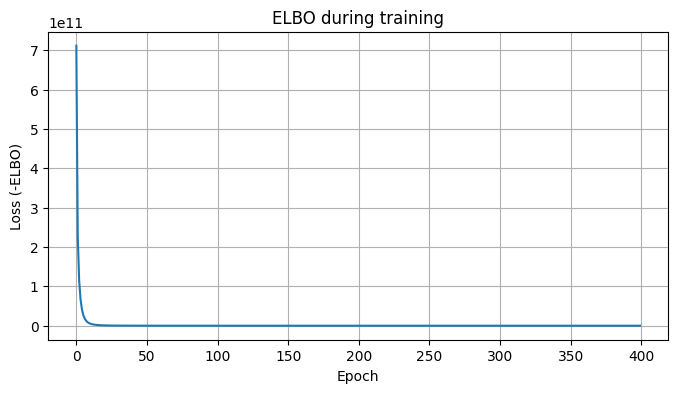

[711635751056.0, 227122949712.0, 114891518808.0, 66224373670.0, 40806351249.0, 26357192403.0, 17714556364.0, 12343573475.5, 8892818232.25, 6604297377.5, 5039552378.625, 3938559100.25, 3143005003.25, 2554260708.0, 2109138043.875, 1766016523.375, 1496914584.0, 1282602440.75, 1109569521.78125, 968122667.40625, 851230152.4375, 753624818.46875, 671383129.8125, 601504379.40625, 541690179.984375, 490131584.578125, 445401908.578125, 406361472.234375, 372108613.25, 341905441.8046875, 315144105.5703125, 291329763.4296875, 270056774.1171875, 250975686.9375, 233799507.0, 218291277.796875, 204243263.671875, 191479023.90625, 179848169.5078125, 169226187.7890625, 159496704.80078125, 150565468.9765625, 142348532.19921875, 134772517.7734375, 127773294.4765625, 121296952.65234375, 115289746.14453125, 109710482.3671875, 104518847.46484375, 99680313.04296875, 95163194.4140625, 90940722.45703125, 86988953.93554688, 83284633.04101562, 79808077.39257812, 76541241.10546875, 73467170.69726562, 70572011.2636718

In [148]:
plt.figure(figsize=(8,4))
plt.plot(pipeline_bayesian.named_steps['model'].losses)
plt.title("ELBO during training")
plt.xlabel("Epoch")
plt.ylabel("Loss (-ELBO)")
plt.grid()
plt.show()

losses = pipeline_bayesian.named_steps['model'].losses
print(losses)

## Валидация (прямой прогноз)

In [150]:
def evaluate_model(
    name: str,
    y_true: np.ndarray,
    y_pred: np.ndarray
) -> dict:
    """Вычисление метрик качества.

    Args:
        name: Название модели.
        y_true: Истинные значения.
        y_pred: Предсказанные значения.

    Returns:
        Словарь с метриками RMSE, MAE, R².
    """
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2}


# Оценка на валидации
results_val = []

pred_ridge_val = pipeline_ridge.predict(X_val)
results_val.append(
    evaluate_model('Ridge', lag_label(y_val).to_numpy(), pred_ridge_val)
)

pred_bayes_val = pipeline_bayesian.predict(X_val)
results_val.append(
    evaluate_model('Bayesian SVI', lag_label(y_val).to_numpy(), pred_bayes_val)
)

print('Результаты на валидации (прямой прогноз):')
pd.DataFrame(results_val)

Результаты на валидации (прямой прогноз):


,Model,RMSE,MAE,R2
0,Ridge,118.938720,95.156263,0.818564
1,Bayesian SVI,2828.394614,2822.156416,-101.602023


## Авторегрессионный прогноз

Предсказания предыдущих шагов используются как входные признаки.

Формируем функции для выполнения авторегрессионного предсказания значений ряда.

In [151]:
def autoregressive_forecast_classic_pipeline(
    pipeline: Pipeline,
    test_data: pd.DataFrame,
    num_lags: int,
    target_col: str = 'Load Demand (kW)'
) -> np.ndarray:
    """Авторегрессионный прогноз для классических моделей.

    Args:
        pipeline: Обученный sklearn pipeline.
        test_data: Тестовые данные.
        num_lags: Число лагов.
        target_col: Имя целевой колонки.

    Returns:
        Массив предсказаний.
    """
    df_test = test_data.copy().reset_index(drop=True)
    df_test[target_col][num_lags:] = np.nan
    y_preds = []

    for i in range(0, len(df_test.index) - num_lags):
        y_pred = pipeline.predict(df_test[i:i + num_lags + 1])
        df_test["Load Demand (kW)"].iloc[i + num_lags] = y_pred
        y_preds.append(y_pred)

    return np.concatenate(y_preds)

In [152]:
def autoregressive_forecast_bayesian_pipeline(
    pipeline: Pipeline,
    test_data: pd.DataFrame,
    num_lags: int,
    num_pred_samples: int = 1024,
    target_col: str = 'Load Demand (kW)'
) -> Tuple[np.ndarray, np.ndarray]:
    """Авторегрессионный прогноз для байесовской модели.

    Args:
        pipeline: Обученный sklearn pipeline.
        test_data: Тестовые данные.
        num_lags: Число лагов.
        num_pred_samples: Число MC-сэмплов для неопределённости.
        target_col: Имя целевой колонки.

    Returns:
        Кортеж (средние предсказания, стандартные отклонения).
    """
    df_test = test_data.copy().reset_index(drop=True)
    df_test[target_col][num_lags:] = np.nan
    y_preds_mean = []
    y_preds_std = []

    for i in range(0, len(df_test.index) - num_lags):
        y_pred = pipeline.predict(
            df_test[i:i + num_lags + 1],
            num_pred_samples=num_pred_samples,
            return_samples=True
        )
        y_pred_mean = y_pred.mean(axis=1)
        y_pred_std = y_pred.std(axis=1)

        df_test["Load Demand (kW)"].iloc[i + num_lags] = y_pred_mean
        y_preds_mean.append(y_pred_mean)
        y_preds_std.append(y_pred_std)

    return np.concatenate(y_preds_mean), np.concatenate(y_preds_std)

Выполняем авторегрессионное прогнозирование для обеих моделей.

In [153]:
# Авторегрессионные прогнозы

# print('Ridge AR...')
# pred_ridge_ar = autoregressive_forecast_classic_pipeline(
#     pipeline_ridge,
#     X_test,
#     num_lags=N_LAGS
# )

# print('Bayesian SVI AR...')
# pred_bayes_ar, std_bayes_ar = autoregressive_forecast_bayesian_pipeline(
#     pipeline_bayesian,
#     X_test,
#     num_lags=N_LAGS
# )

# Авторегрессионные прогнозы
print('Ridge AR...')
pred_ridge_ar = autoregressive_forecast_classic_pipeline(
    pipeline_ridge,
    df[val_end:],
    num_lags=N_LAGS
)

print('Bayesian SVI AR...')
pred_bayes_ar, std_bayes_ar = autoregressive_forecast_bayesian_pipeline(
    pipeline_bayesian,
    df[val_end:],
    num_lags=N_LAGS
)

print('Авторегрессионные прогнозы получены')



Ridge AR...
Bayesian SVI AR...
Авторегрессионные прогнозы получены


## Финальные метрики на тестовых данных

In [155]:
# Метрики в авторегрессионном режиме
results_test = []
results_test.append(
    evaluate_model('Ridge (AR)', lag_label(y_test).to_numpy(), pred_ridge_ar)
)
results_test.append(
    evaluate_model(
        'Bayesian SVI (AR)', lag_label(y_test).to_numpy(), pred_bayes_ar
    )
)

df_results = pd.DataFrame(results_test)
print('Результаты авторегрессионного прогноза на тестовых данных:')
df_results

Результаты авторегрессионного прогноза на тестовых данных:


,Model,RMSE,MAE,R2
0,Ridge (AR),276.111770,222.267577,0.001765
1,Bayesian SVI (AR),4148.624025,4143.030114,-224.356996


## Визуализация: временные ряды авторегрессионных предсказаний

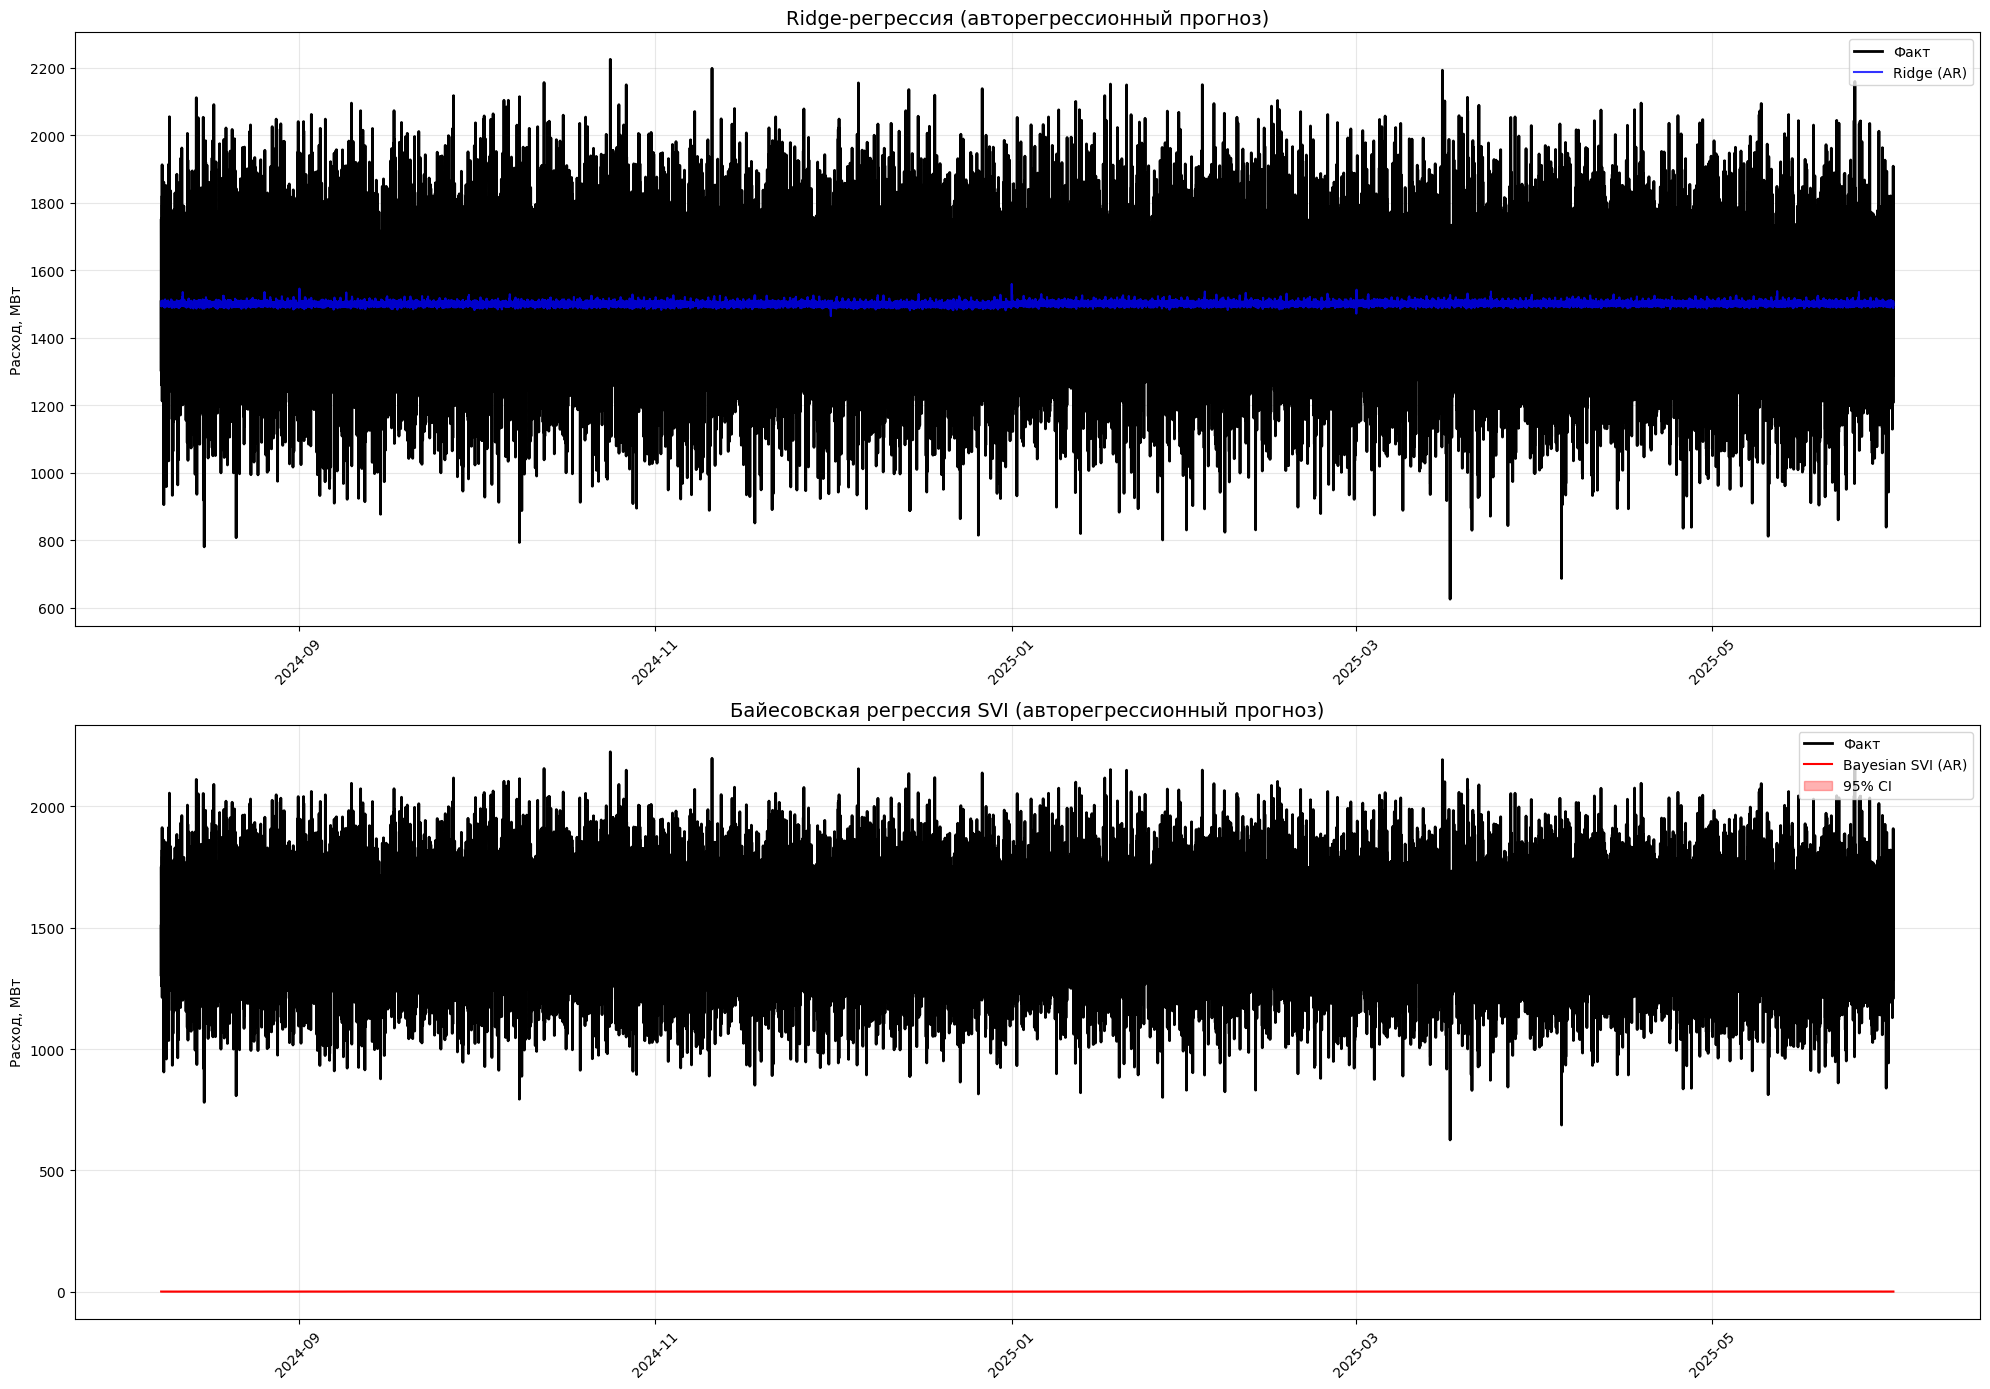

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(20, 14))

# Ridge AR
axes[0].plot(
    dates_test[N_LAGS:], lag_label(y_test).to_numpy(),
    'k-', linewidth=2, label='Факт'
)
axes[0].plot(
    dates_test[N_LAGS:], pred_ridge_ar,
    'b-', linewidth=1.5, alpha=0.8, label='Ridge (AR)'
)
axes[0].set_ylabel('Расход, МВт')
axes[0].set_title(
    'Ridge-регрессия (авторегрессионный прогноз)', fontsize=14
)
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Bayesian SVI AR с доверительным интервалом
axes[1].plot(
    dates_test[N_LAGS:], lag_label(y_test).to_numpy(),
    'k-', linewidth=2, label='Факт'
)
axes[1].plot(
    dates_test[N_LAGS:], pred_bayes_ar,
    'r-', linewidth=1.5, label='Bayesian SVI (AR)'
)
axes[1].fill_between(
    dates_test[N_LAGS:],
    pred_bayes_ar - 1.96 * std_bayes_ar,
    pred_bayes_ar + 1.96 * std_bayes_ar,
    alpha=0.3, color='red', label='95% CI'
)
axes[1].set_ylabel('Расход, МВт')
axes[1].set_title(
    'Байесовская регрессия SVI (авторегрессионный прогноз)', fontsize=14
)
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

# Форматирование дат
for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.tight_layout()
plt.show()

## Scatter plots: сравнение фактических и прогнозных значений ряда

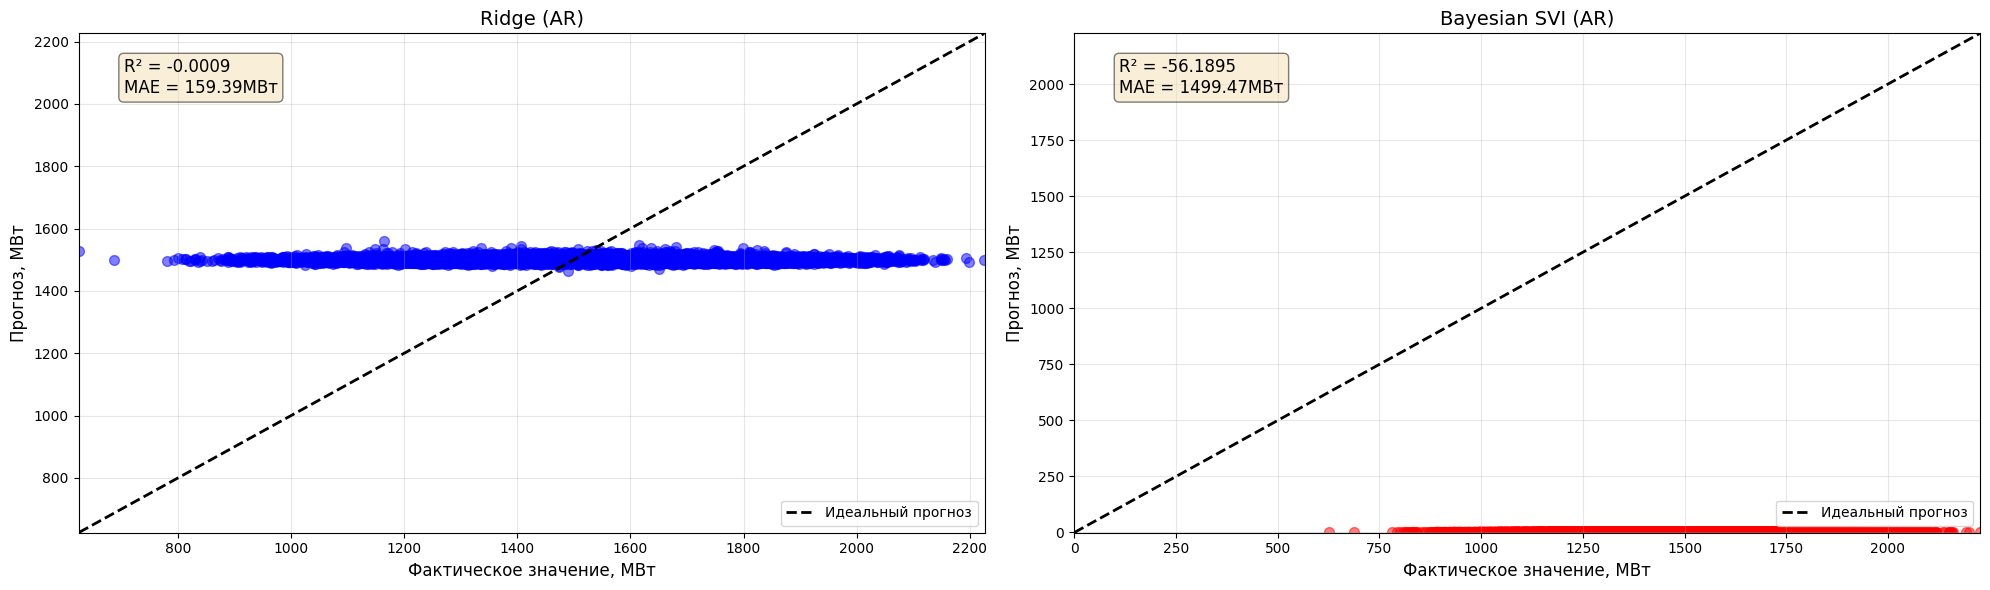

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

models_data = [
    ('Ridge (AR)', pred_ridge_ar, 'blue'),
    ('Bayesian SVI (AR)', pred_bayes_ar, 'red')
]

y_true = lag_label(y_test).to_numpy()

for ax, (name, pred, color) in zip(axes, models_data):
    ax.scatter(y_true, pred, alpha=0.5, c=color, s=50)

    min_val = min(y_true.min(), pred.min())
    max_val = max(y_true.max(), pred.max())
    ax.plot(
        [min_val, max_val], [min_val, max_val],
        'k--', linewidth=2, label='Идеальный прогноз'
    )

    ax.set_xlim(min_val - 1, max_val + 1)
    ax.set_ylim(min_val - 1, max_val + 1)

    r2 = r2_score(y_true, pred)
    mae = mean_absolute_error(y_true, pred)
    ax.text(
        0.05, 0.95, f'R² = {r2:.4f}\nMAE = {mae:.2f}МВт',
        transform=ax.transAxes, fontsize=12, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    )

    ax.set_xlabel('Фактическое значение, МВт', fontsize=12)
    ax.set_ylabel('Прогноз, МВт', fontsize=12)
    ax.set_title(f'{name}', fontsize=14)
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Распределение ошибок моделей

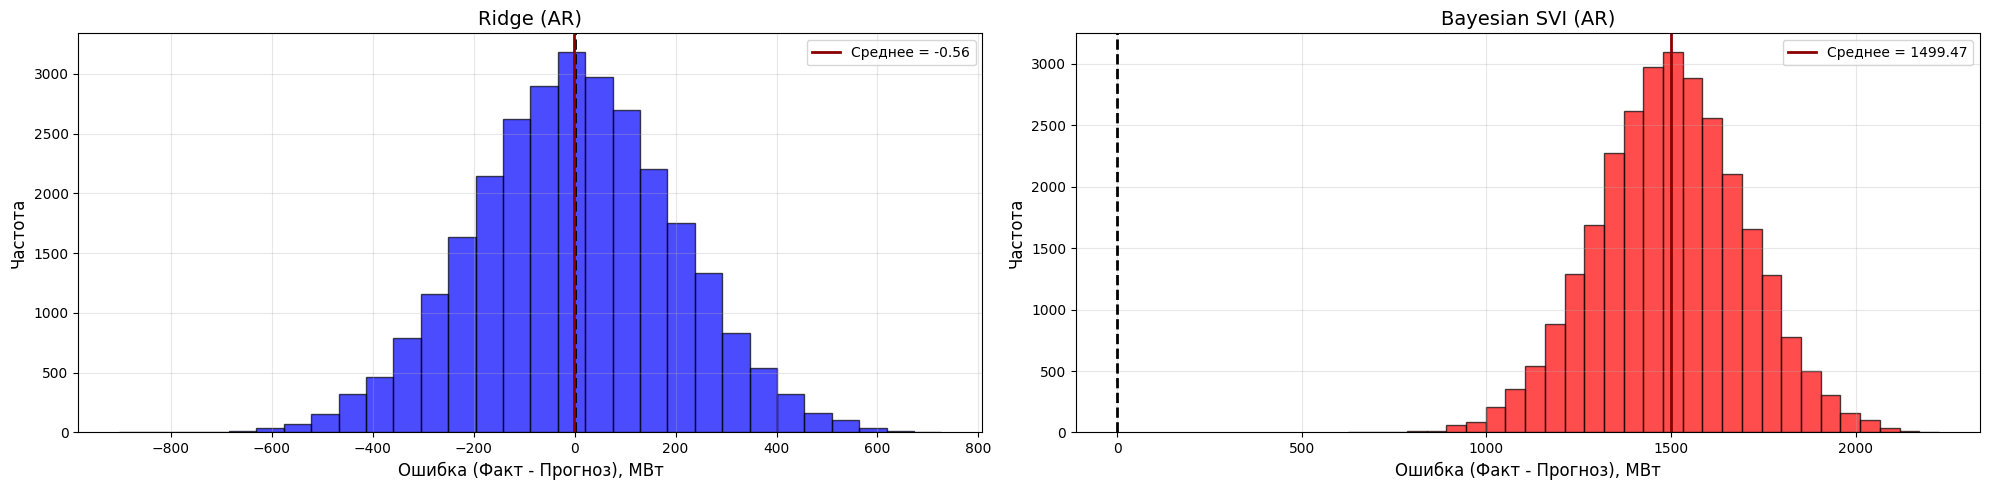

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 5))

y_true = lag_label(y_test).to_numpy()

errors_data = [
    ('Ridge (AR)', y_true - pred_ridge_ar, 'blue'),
    ('Bayesian SVI (AR)', y_true - pred_bayes_ar, 'red')
]

for ax, (name, errors, color) in zip(axes, errors_data):
    ax.hist(errors, bins=30, color=color, alpha=0.7, edgecolor='black')
    ax.axvline(x=0, color='black', linestyle='--', linewidth=2)
    ax.axvline(
        x=errors.mean(), color='darkred', linestyle='-', linewidth=2,
        label=f'Среднее = {errors.mean():.2f}'
    )

    ax.set_xlabel('Ошибка (Факт - Прогноз), МВт', fontsize=12)
    ax.set_ylabel('Частота', fontsize=12)
    ax.set_title(f'{name}', fontsize=14)
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Сравнение метрик на тестовых данных

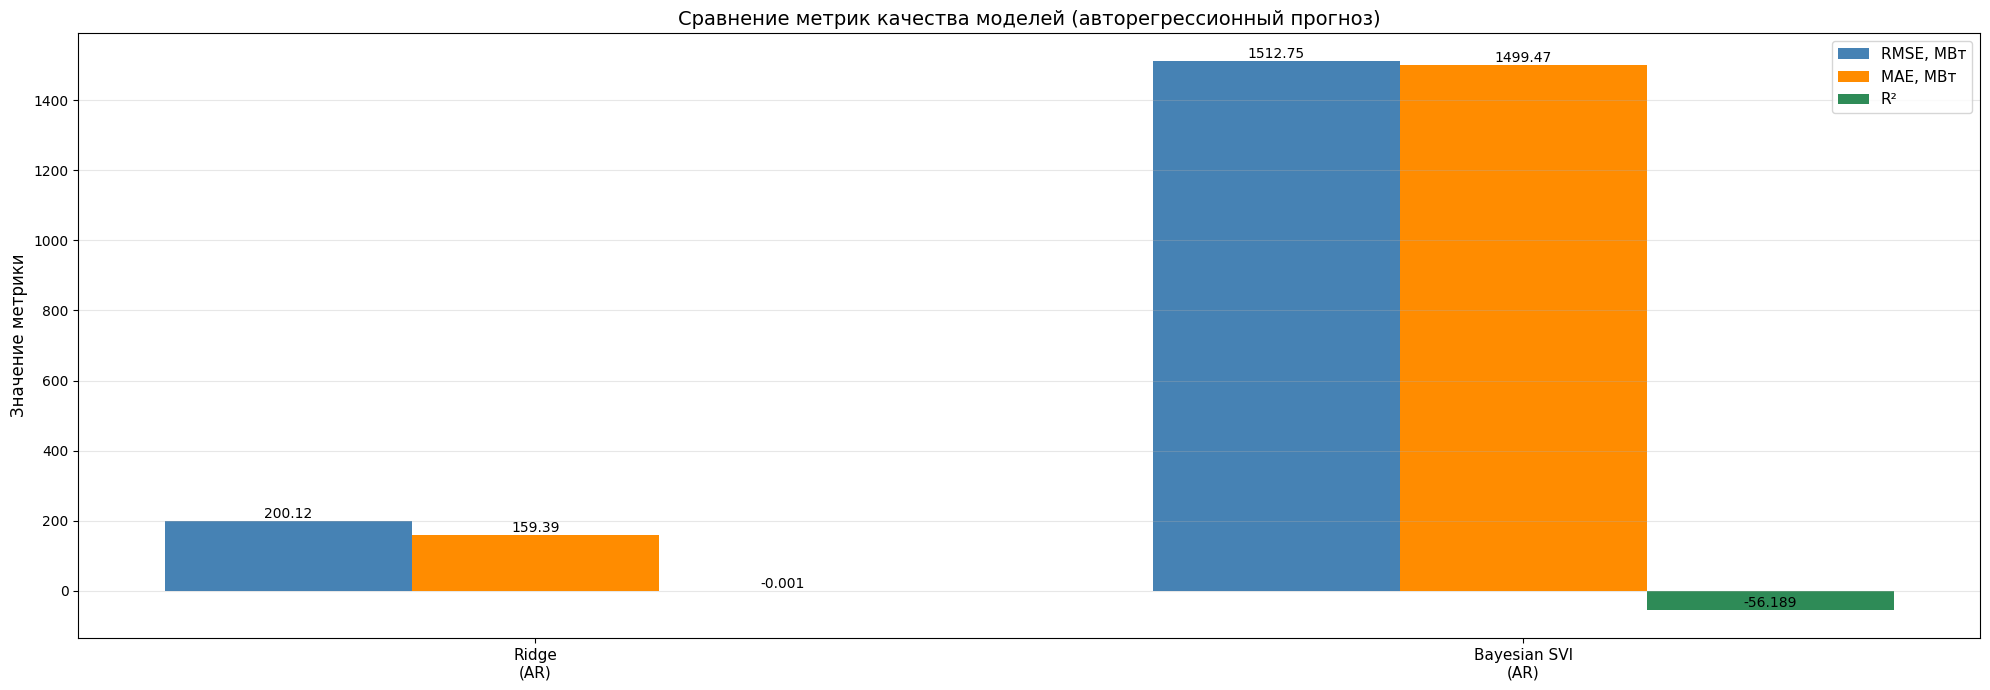

In [ ]:
fig, ax = plt.subplots(figsize=(20, 7))

models = ['Ridge\n(AR)', 'Bayesian SVI\n(AR)']
predictions = [pred_ridge_ar, pred_bayes_ar]
y_true = lag_label(y_test).to_numpy()

# Расчёт метрик
rmse_vals = [
    np.sqrt(mean_squared_error(y_true, p)) for p in predictions
]
mae_vals = [mean_absolute_error(y_true, p) for p in predictions]
r2_vals = [r2_score(y_true, p) for p in predictions]

x = np.arange(len(models))
width = 0.25

bars1 = ax.bar(x - width, rmse_vals, width, label='RMSE, МВт', color='steelblue')
bars2 = ax.bar(x, mae_vals, width, label='MAE, МВт', color='darkorange')
bars3 = ax.bar(x + width, r2_vals, width, label='R²', color='seagreen')

ax.set_ylabel('Значение метрики', fontsize=12)
ax.set_title(
    'Сравнение метрик качества моделей (авторегрессионный прогноз)',
    fontsize=14
)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

# Подписи значений над столбцами
for bar, val in zip(bars1, rmse_vals):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
        f'{val:.2f}', ha='center', va='bottom', fontsize=10
    )
for bar, val in zip(bars2, mae_vals):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
        f'{val:.2f}', ha='center', va='bottom', fontsize=10
    )
for bar, val in zip(bars3, r2_vals):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
        f'{val:.3f}', ha='center', va='bottom', fontsize=10
    )

plt.tight_layout()
plt.show()

## Индивидуальное задание

Опираясь на представленное исследование и используя его в качестве образца, **выполните аналогичные действия с выбранным Вами датасетом**.

В процессе работы:

1. Выберите датасет, содержащий **временной ряд**. Датасеты можно найти, например, на [Kaggle](https://www.kaggle.com/datasets) и [UC Irvine Machine Learning Repository](https://archive.ics.uci.edu/ml/index.php). Датасет должен содержать целевую переменную и **хотя бы один** дополнительный признак.

2. Выполните **разведочный анализ** датасета: исследуйте временную структуру, сезонность, тренды. Выполните требуемые **преобразования признаков** (масштабирование, бинаризация и др.).

3. Разделите датасет на **обучающую**, **валидационную** и **тестовую** части с сохранением временного порядка.

4. Реализуйте **трансформер лаговых признаков** для построения авторегрессионной модели заданного порядка $p$.

5. Реализуйте **Ridge-регрессию** с автоматическим подбором коэффициента регуляризации через кросс-валидацию по временным рядам (TimeSeriesSplit).

6. Составьте **байесовскую линейную модель** для решения задачи регрессии. Запишите априорные распределения весов, правдоподобие и вид апостериорного распределения.

7. Реализуйте байесовскую модель на **PyTorch** с использованием **стохастического вариационного вывода (SVI)**. Используйте Mean-Field приближение и трюк репараметризации.

8. **Обучите** обе модели. Для байесовской модели визуализируйте значения ELBO в процессе обучения.

9. Разработайте процедуру **авторегрессионного прогнозирования** для обеих моделей: предсказания предыдущих шагов должны использоваться как входные признаки для следующих.

10. **Визуализируйте** прогнозы обеих моделей на тестовой выборке. Для байесовской модели отобразите **доверительные интервалы** (95% CI).

11. **Вычислите метрики качества** (RMSE, MAE, R²) для обеих моделей в авторегрессионном режиме. Критически оцените полученные результаты.

12. Постройте **scatter-диаграммы** «факт и прогноз» и **гистограммы ошибок** для обеих моделей.

13. Проведите **сравнительный анализ** частотного и байесовского подходов: точность, качество оценки неопределённости, вычислительная сложность.

14. Сделайте **выводы** по работе.



## Вопросы для подготовки к отчёту

1. Основные понятия теории вероятностей: плотность распределения, правило нормировки, совместная плотность вероятности, математическое ожидание, дисперсия, условная плотность вероятности. Условная независимость.

2. Обращение условного распределения. Теорема Байеса и роль каждого из её компонентов в байесовском моделировании.

3. Понятие графических вероятностных моделей. Представление вероятностных отношений в виде графа. Байесовская сеть. Наблюдаемые и латентные величины, их обозначения в графических моделях. Нотация «планок» в графических моделях. Глобальные и локальные латентные переменные. Примеры.

4. Классический и байесовский подходы к машинному обучению, их сравнительный анализ. Пример линейной регрессии с точки зрения обоих подходов. Постановка задачи и основная проблема байесовского вывода, способы её решения.

5. Понятие сэмплирования случайной величины. Способы сэмплирования. Теорема об обратной функции распределения и её применение для сэмплирования. Сэмплирование с отклонением (Rejection sampling). Сэмплирование по важности (Importance sampling). Forward sampling.

6. Вариационный инференс как метод решения задачи байесовского вывода. Идея вариационного инференса. Дивергенция Кульбака-Лейблера в задаче вариационного инференса. Вариационная нижняя оценка правдоподобия данных.

7. Вариационный инференс как оптимизационная задача. Стохастический вариационный инференс. Проблема расчёта градиента от оценки математического ожидания. Трюк репараметризации. Пример для нормального распределения.

8. Амортизированный вариационный инференс: назначение, сущность и особенности.  Отличие амортизированного инференса от классического вариационного вывода. Понятие Inference Network, примеры архитектур.

9. Понятие байесовских нейронных сетей. Отличие от классических нейронных сетей. Построение байесовской нейронной сети. Виды неопределённости: эпистемическая и алеаторическая.

10. Авторегрессионные модели: определение, структура, область применения. Авторегрессионная модель порядка $p$. Выражение для факторизации совместного распределения переменных временного ряда, порождаемого AR-моделью.  Авторегрессионное прогнозирование, накопление ошибки и неопределённости при многошаговом прогнозе.


## Список рекомендуемой литературы

1. Дауни, А. Б. Байесовские модели / А. Б. Дауни ; перевод с английского В. А. Яроцкого. — Москва : ДМК Пресс, 2018. — 182 с. URL: https://e.lanbook.com/book/131695 (дата обращения: 13.02.2024). — Режим доступа: для авториз. пользователей.

2. Barber, D. Bayesian Reasoning and Machine Learning / D. Barber // Cambridge University Press, 2012. URL: [http://www0.cs.ucl.ac.uk/staff/d.barber/brml/](http://www0.cs.ucl.ac.uk/staff/d.barber/brml/) (дата обращения: 13.02.2024).

3. Bishop, M.C. Pattern Recognition and Machine Learning / M.C. Bishop // Springer, 2006. — 738 с. URL: [https://www.microsoft.com/en-us/research/uploads/prod/2006/01/Bishop-Pattern-Recognition-and-Machine-Learning-2006.pdf](https://www.microsoft.com/en-us/research/uploads/prod/2006/01/Bishop-Pattern-Recognition-and-Machine-Learning-2006.pdf) (дата обращения: 13.02.2024).

4. Hoffman M., Blei D. M, Wang C., Paisley J. Stochastic Variational Inference [Электронный ресурс] // arXiv.org. 2013. Дата обновления: 22.04.2013. URL: https://arxiv.org/abs/1206.7051 (дата обращения: 22.05.2024).

5. Ranganath R., Gerrish S., Blei D.M. Black Box Variational Inference [Электронный ресурс] // arXiv.org. 2013. Дата обновления: 31.12.2013. URL: https://arxiv.org/pdf/1401.0118 (дата обращения: 22.05.2024).

6. Ganguly A., Jain S., Watchareeruetai U. Amortized Variational Inference: A Systematic Review [Электронный ресурс] // arXiv.org. 2023. Дата обновления: 24.10.2013. URL: https://arxiv.org/pdf/2209.10888

7. Box G. E. P., Jenkins G. M., Reinsel G. C. Time Series Analysis: Forecasting and Control. — 4th ed. — Wiley, 2015. — 720 с.